In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset
df = pd.read_csv("Unemployment in India.csv")

In [3]:
# Display first five rows
print(df.head())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  


In [4]:
# Dataset Information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
None


In [5]:
# Check Missing Values
print(df.isnull().sum())

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


In [6]:
# Remove Extra Spaces from Column Names
df.columns = df.columns.str.strip()

# Convert Date Column
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Dataset Statistics
print(df.describe())

                                Date  Estimated Unemployment Rate (%)  \
count                            740                       740.000000   
mean   2019-12-12 18:36:58.378378496                        11.787946   
min              2019-05-31 00:00:00                         0.000000   
25%              2019-08-31 00:00:00                         4.657500   
50%              2019-11-30 00:00:00                         8.350000   
75%              2020-03-31 00:00:00                        15.887500   
max              2020-06-30 00:00:00                        76.740000   
std                              NaN                        10.721298   

       Estimated Employed  Estimated Labour Participation Rate (%)  
count        7.400000e+02                               740.000000  
mean         7.204460e+06                                42.630122  
min          4.942000e+04                                13.330000  
25%          1.190404e+06                                38.062500

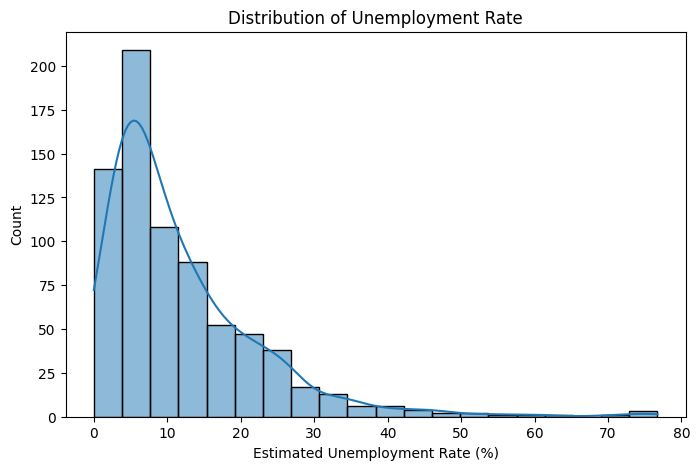

In [7]:
# Unemployment Rate Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["Estimated Unemployment Rate (%)"], bins=20, kde=True)
plt.title("Distribution of Unemployment Rate")
plt.show()

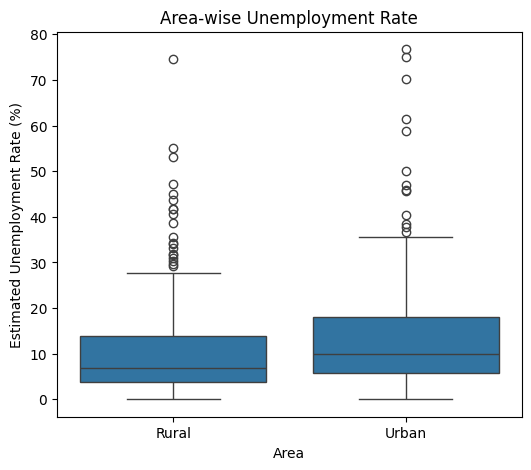

In [8]:
# Area-wise Unemployment

plt.figure(figsize=(6,5))
sns.boxplot(x="Area", y="Estimated Unemployment Rate (%)", data=df)
plt.title("Area-wise Unemployment Rate")
plt.show()

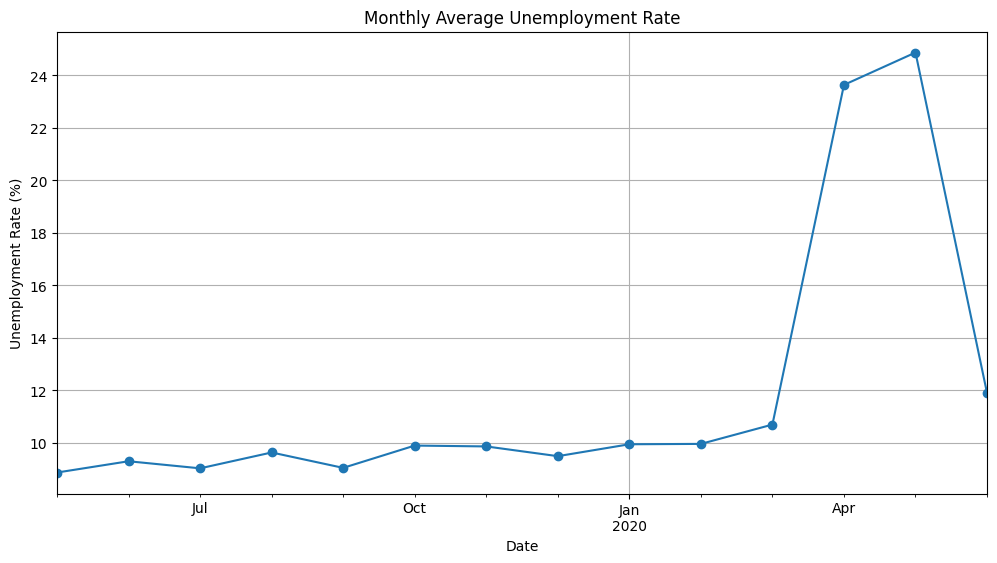

In [9]:
# Monthly Trend

monthly = df.groupby("Date")["Estimated Unemployment Rate (%)"].mean()

plt.figure(figsize=(12,6))
monthly.plot(marker='o')
plt.title("Monthly Average Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

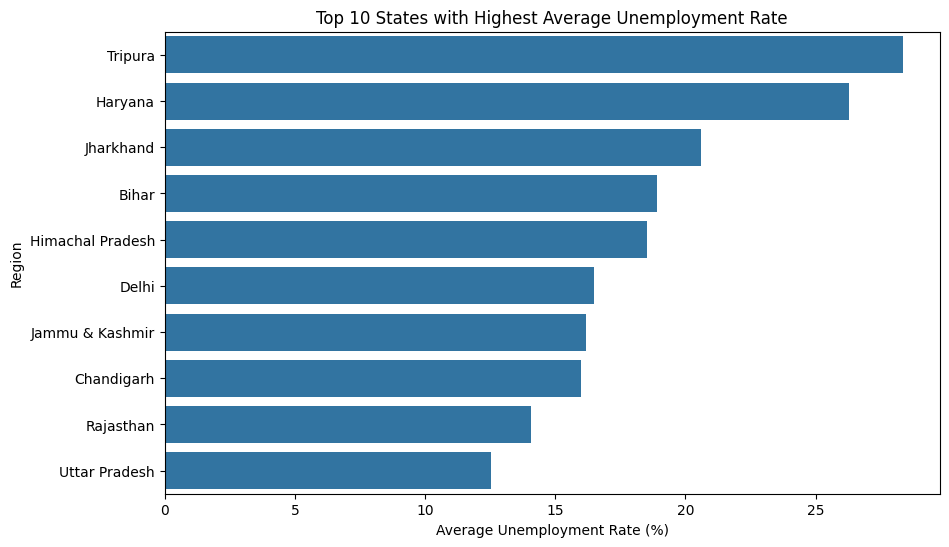

In [10]:
# Top 10 States

top_states = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_states.values, y=top_states.index)
plt.title("Top 10 States with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.show()

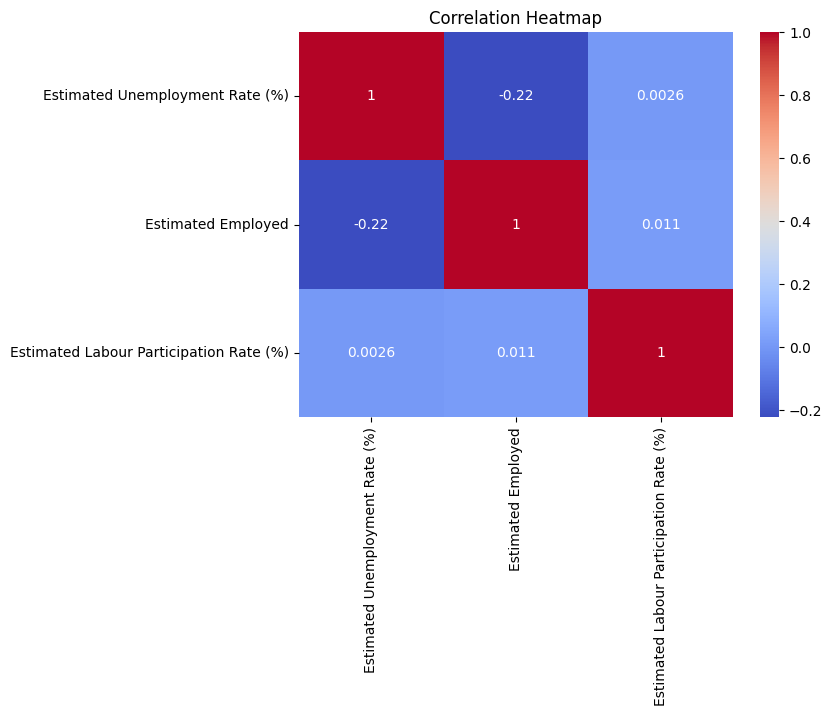

In [11]:
# Correlation Heatmap

plt.figure(figsize=(7,5))

corr = df[[
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()